## Network Intrusion Detection
### Principles of AI - Machine Learning Assignment

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

#### Getting the Dataset

In [3]:
# !kaggle datasets list -s NSL-KDD
# !kaggle datasets list -s hassan06/nslkdd
!kaggle datasets download -d hassan06/nslkdd

Dataset URL: https://www.kaggle.com/datasets/hassan06/nslkdd
License(s): unknown




  0%|          | 0.00/13.9M [00:00<?, ?B/s]
  7%|▋         | 1.00M/13.9M [00:00<00:09, 1.43MB/s]
 14%|█▍        | 2.00M/13.9M [00:00<00:04, 2.90MB/s]
 29%|██▉       | 4.00M/13.9M [00:01<00:01, 5.21MB/s]
 51%|█████     | 7.00M/13.9M [00:01<00:00, 9.21MB/s]
 65%|██████▍   | 9.00M/13.9M [00:01<00:00, 11.3MB/s]
 79%|███████▉  | 11.0M/13.9M [00:01<00:00, 13.0MB/s]
100%|██████████| 13.9M/13.9M [00:01<00:00, 15.4MB/s]
100%|██████████| 13.9M/13.9M [00:01<00:00, 9.33MB/s]


---

#### Exploratory Analysis

In [8]:
train_path = 'nsl-kdd/KDDTrain+.txt'
train_file = pd.read_csv(train_path, header=None)

In [9]:
print('Shape:', train_file.shape)
print("\nFirst 5 rows (head):")
print(train_file.head())

Shape: (125973, 43)

First 5 rows (head):
   0    1         2   3    4     5   6   7   8   9   ...    33    34    35  \
0   0  tcp  ftp_data  SF  491     0   0   0   0   0  ...  0.17  0.03  0.17   
1   0  udp     other  SF  146     0   0   0   0   0  ...  0.00  0.60  0.88   
2   0  tcp   private  S0    0     0   0   0   0   0  ...  0.10  0.05  0.00   
3   0  tcp      http  SF  232  8153   0   0   0   0  ...  1.00  0.00  0.03   
4   0  tcp      http  SF  199   420   0   0   0   0  ...  1.00  0.00  0.00   

     36    37    38    39    40       41  42  
0  0.00  0.00  0.00  0.05  0.00   normal  20  
1  0.00  0.00  0.00  0.00  0.00   normal  15  
2  0.00  1.00  1.00  0.00  0.00  neptune  19  
3  0.04  0.03  0.01  0.00  0.01   normal  21  
4  0.00  0.00  0.00  0.00  0.00   normal  21  

[5 rows x 43 columns]


In [11]:
print("Info:")
print(train_file.info())

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       125973 non-null  int64  
 1   1       125973 non-null  object 
 2   2       125973 non-null  object 
 3   3       125973 non-null  object 
 4   4       125973 non-null  int64  
 5   5       125973 non-null  int64  
 6   6       125973 non-null  int64  
 7   7       125973 non-null  int64  
 8   8       125973 non-null  int64  
 9   9       125973 non-null  int64  
 10  10      125973 non-null  int64  
 11  11      125973 non-null  int64  
 12  12      125973 non-null  int64  
 13  13      125973 non-null  int64  
 14  14      125973 non-null  int64  
 15  15      125973 non-null  int64  
 16  16      125973 non-null  int64  
 17  17      125973 non-null  int64  
 18  18      125973 non-null  int64  
 19  19      125973 non-null  int64  
 20  20      125973 non-null  int64  
 21  21  

In [12]:
print("Missing values per column:")
print(train_file.isna().sum())

Missing values per column:
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
32    0
33    0
34    0
35    0
36    0
37    0
38    0
39    0
40    0
41    0
42    0
dtype: int64


In [13]:
cols = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty"
]

train_file.columns = cols

##### Class Distribution
Imbalanced, but realistic for network traffic

**Distribution:**
- Normal:               67,343
- Frequent (> 1000):    ~ 55,000
- Medium (100 - 1000):  ~ 5,000
- Rare (< 100):         ~ 167
- Very Rare (< 10):     ~ 50

**Dominant Attack Types:**
- neptune  :    41,214      - massive DoS attack
- satan    :    3633        - scanning / probing
- ipsweep  :    3599        - network sweep
- portsweep:    2931
- smurf    :    2646
- nmap     :    1493

**Very Rare Attack Types:**
- loadmodule:   9
- ftp_write :   8
- multihop  :   7
- phf       :   4
- perl      :   3
- spy       :   2

In [28]:
label_counts = train_file['label'].value_counts()
print(label_counts)

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


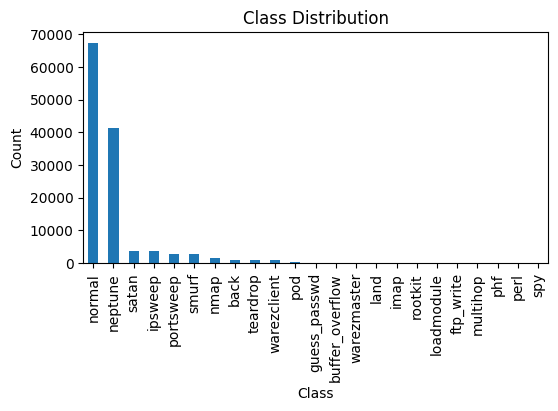

In [29]:
plt.figure(figsize = (6, 3))
label_counts.plot(kind = 'bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

##### Numerical Feature Distribution

- Normal behavior: small packets, quick connections $\Rightarrow$ most numeric features are skewed $\Rightarrow$ needs scaling
- Attacks often create big bursts or unusual sequences $\Rightarrow$ anomalies stick out dramatically
- `srv_count` & `count` peaks:
    - very low values = normal traffic
    - medium values = scanning / probing
    - high values = heavy DoS attacks

In [24]:
numeric_cols = train_file.select_dtypes(include = np.number).columns
key_features = [ 'duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count' ]
train_file[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03


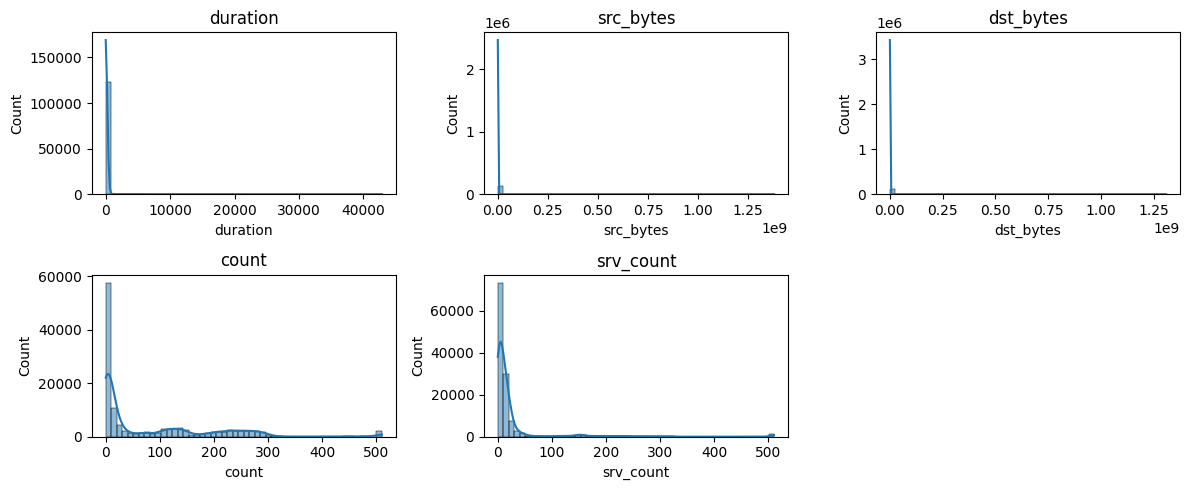

In [26]:
plt.figure(figsize = (12, 5))
for i, col in enumerate(key_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(train_file[col], bins = 50, kde = True)
    plt.title(col)

plt.tight_layout()
plt.show()

##### Correlation Matrix

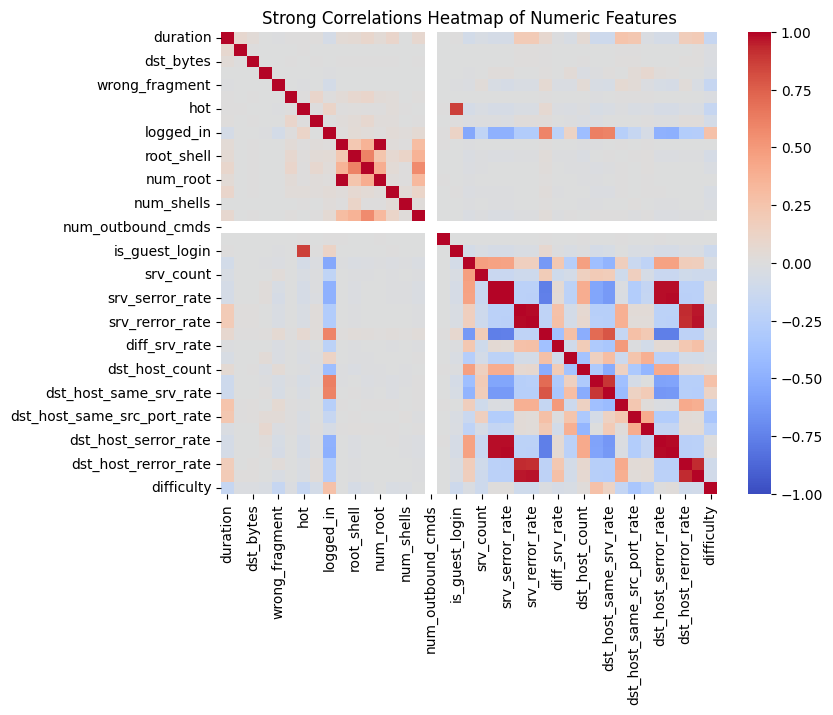

In [33]:
plt.figure(figsize = (8, 6))
correlation = train_file[numeric_cols].corr()

sns.heatmap(correlation, cmap = 'coolwarm', vmax = 1.0, vmin = -1.0)
plt.title('Strong Correlations Heatmap of Numeric Features')
plt.show()